In [1]:
# load the necessary packages
library("tidyverse")
library("lme4")
library("emmeans")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



In [2]:
R.version.string

[1] "R version 4.5.3 (2026-03-11 ucrt)"

In [3]:
packageVersion("lme4")
packageVersion("emmeans")

[1] '1.1.38'

[1] '2.0.3'

In [4]:
# load the data
data <- read.csv('df_ampw_vs_loss.csv')

In [5]:
data$upper_bound <- as.factor(data$upper_bound)

In [6]:
model = lmer(loss ~ 1 + ampw*v1_unit*upper_bound + (1+ampw|dlgn_unit), data = data)

In [7]:
summary(model)

Linear mixed model fit by REML ['lmerMod']
Formula: loss ~ 1 + ampw * v1_unit * upper_bound + (1 + ampw | dlgn_unit)
   Data: data

REML criterion at convergence: -102615

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.6950 -0.5165 -0.1444  0.3476 11.9477 

Random effects:
 Groups    Name        Variance  Std.Dev. Corr 
 dlgn_unit (Intercept) 4.504e-05 0.006711      
           ampw        2.898e-02 0.170249 -0.26
 Residual              1.939e-04 0.013926      
Number of obs: 18000, groups:  dlgn_unit, 6

Fixed effects:
                               Estimate Std. Error t value
(Intercept)                   0.0580789  0.0088216   6.584
ampw                          0.9443391  0.2255027   4.188
v1_unit                       0.0073706  0.0055687   1.324
upper_bound0.16               0.0046119  0.0019672   2.344
upper_bound0.24               0.0193422  0.0020313   9.522
ampw:v1_unit                 -0.4022146  0.1424860  -2.823
ampw:upper_bound0.16         -0.0732061  0.05

In [8]:
## Test the significance of each effect

effect_significance = data.frame(joint_tests(model))
effect_significance

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,model.term,df1,df2,F.ratio,Chisq,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ampw,1,Inf,15.751,15.751,7.225517e-05
5,v1_unit,1,Inf,1.908,1.908,1.671583e-01
7,upper_bound,2,Inf,526.591,1053.182,2.016442e-229
2,ampw:v1_unit,1,Inf,6.489,6.489,1.085668e-02
4,ampw:upper_bound,2,Inf,88.944,177.888,2.355110e-39
6,v1_unit:upper_bound,2,Inf,31.468,62.936,2.156785e-14
3,ampw:v1_unit:upper_bound,2,Inf,32.682,65.364,6.402120e-15


In [9]:
## get the predicted intercept for each group

intercept_pred = emmeans(
    model, 
    pairwise ~ v1_unit*upper_bound|ampw,
    at = list(ampw = c(0.0)) 
)$emmeans %>% data.frame()
intercept_pred

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



,v1_unit,upper_bound,ampw,emmean,SE,df,asymp.LCL,asymp.UCL
,<int>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,0.08,0,0.06544954,0.003950114,Inf,0.05770746,0.07319162
2,2,0.08,0,0.07282019,0.003925126,Inf,0.06512709,0.08051330
3,1,0.16,0,0.07129287,0.003919010,Inf,0.06361175,0.07897399
4,2,0.16,0,0.07989497,0.003916775,Inf,0.07221823,0.08757170
5,1,0.24,0,0.08417613,0.003921739,Inf,0.07648967,0.09186260
6,2,0.24,0,0.09093112,0.003929880,Inf,0.08322870,0.09863355


In [10]:
## Get intercept contrasts
intercept_contrasts = emmeans(
    model, 
    pairwise ~ upper_bound|ampw,
    at = list(ampw = c(0.0)) 
)$emmeans  %>% pairs()  %>% data.frame()

intercept_contrasts

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

NOTE: Results may be misleading due to involvement in interactions



,contrast,ampw,estimate,SE,df,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,upper_bound0.08 - upper_bound0.16,0,-0.00645905,0.0005834759,Inf,-11.06995,1.465494e-14
2,upper_bound0.08 - upper_bound0.24,0,-0.01841876,0.0006120053,Inf,-30.09575,0.000000e+00
3,upper_bound0.16 - upper_bound0.24,0,-0.01195971,0.0004892131,Inf,-24.44683,0.000000e+00


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



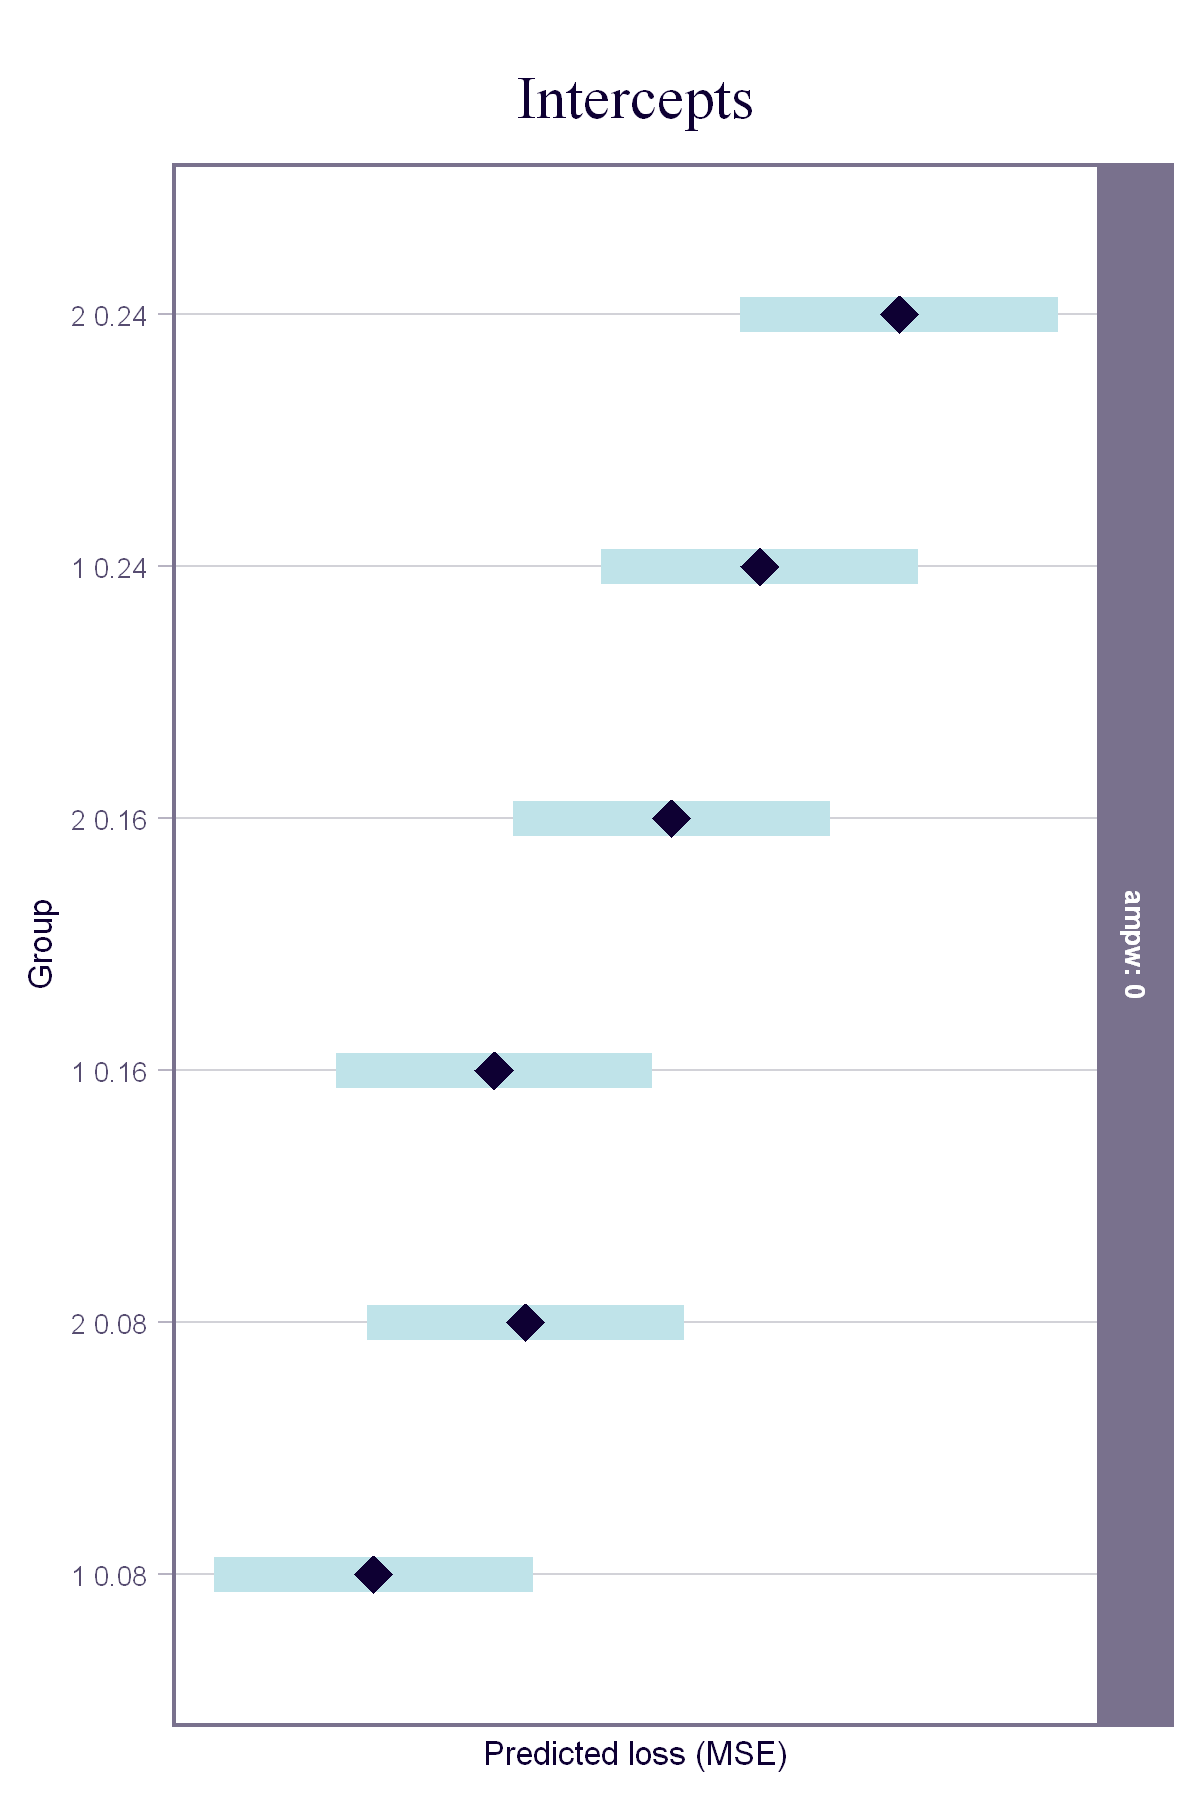

In [11]:
# adjust figure attributes:
options(
    repr.plot.width = 4, 
    repr.plot.height = 6, 
    repr.plot.res = 300
)

emmeans(
    model, 
    pairwise ~ v1_unit+upper_bound|ampw,
    at = list(ampw = c(0.0)) 
)$emmeans %>% plot() +
    labs(
        x = 'Predicted loss (MSE)',
        y = 'Group',
        title = 'Intercepts'
    ) + 
    geom_point(size=0.05) +
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(text = element_text(size = 8)) +
    scale_x_continuous(labels = seq(0,250,10), breaks = seq(0,250,10))

In [12]:
## get the predicted slope for each group

slope_pred = emtrends(
    model, 
    var = 'ampw', 
    specs = c('upper_bound') 
) %>% data.frame()
slope_pred

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

NOTE: Results may be misleading due to involvement in interactions



,upper_bound,ampw.trend,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.08,0.3410171,0.07124298,Inf,0.20138344,0.4806508
2,0.16,0.2878700,0.07017742,Inf,0.15032480,0.4254152
3,0.24,0.2057111,0.07010589,Inf,0.06830611,0.3431162


In [14]:
# ## get the predicted slope for each group

# slope_pred = emtrends(
#     model, 
#     var = 'ampw', 
#     specs = c('upper_bound') 
# ) %>% data.frame()
# slope_pred

# write.csv(slope_pred, 'ampw_slopes_bybounds.csv')

In [16]:
## Get slope contrasts

slope_contrasts = emtrends(
    model, 
    var = 'ampw',
    specs = c('upper_bound') 
)  %>% pairs()  %>% data.frame()
slope_contrasts

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

NOTE: Results may be misleading due to involvement in interactions



,contrast,estimate,SE,df,z.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,upper_bound0.08 - upper_bound0.16,0.05314711,0.015399809,Inf,3.451154,1.617823e-03
2,upper_bound0.08 - upper_bound0.24,0.13530598,0.015375858,Inf,8.799898,2.298162e-14
3,upper_bound0.16 - upper_bound0.24,0.08215887,0.006998236,Inf,11.739940,0.000000e+00


Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 18000' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.

Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 18000' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 18000)' or larger];
but be warned that this may result in large computation time and memory use.



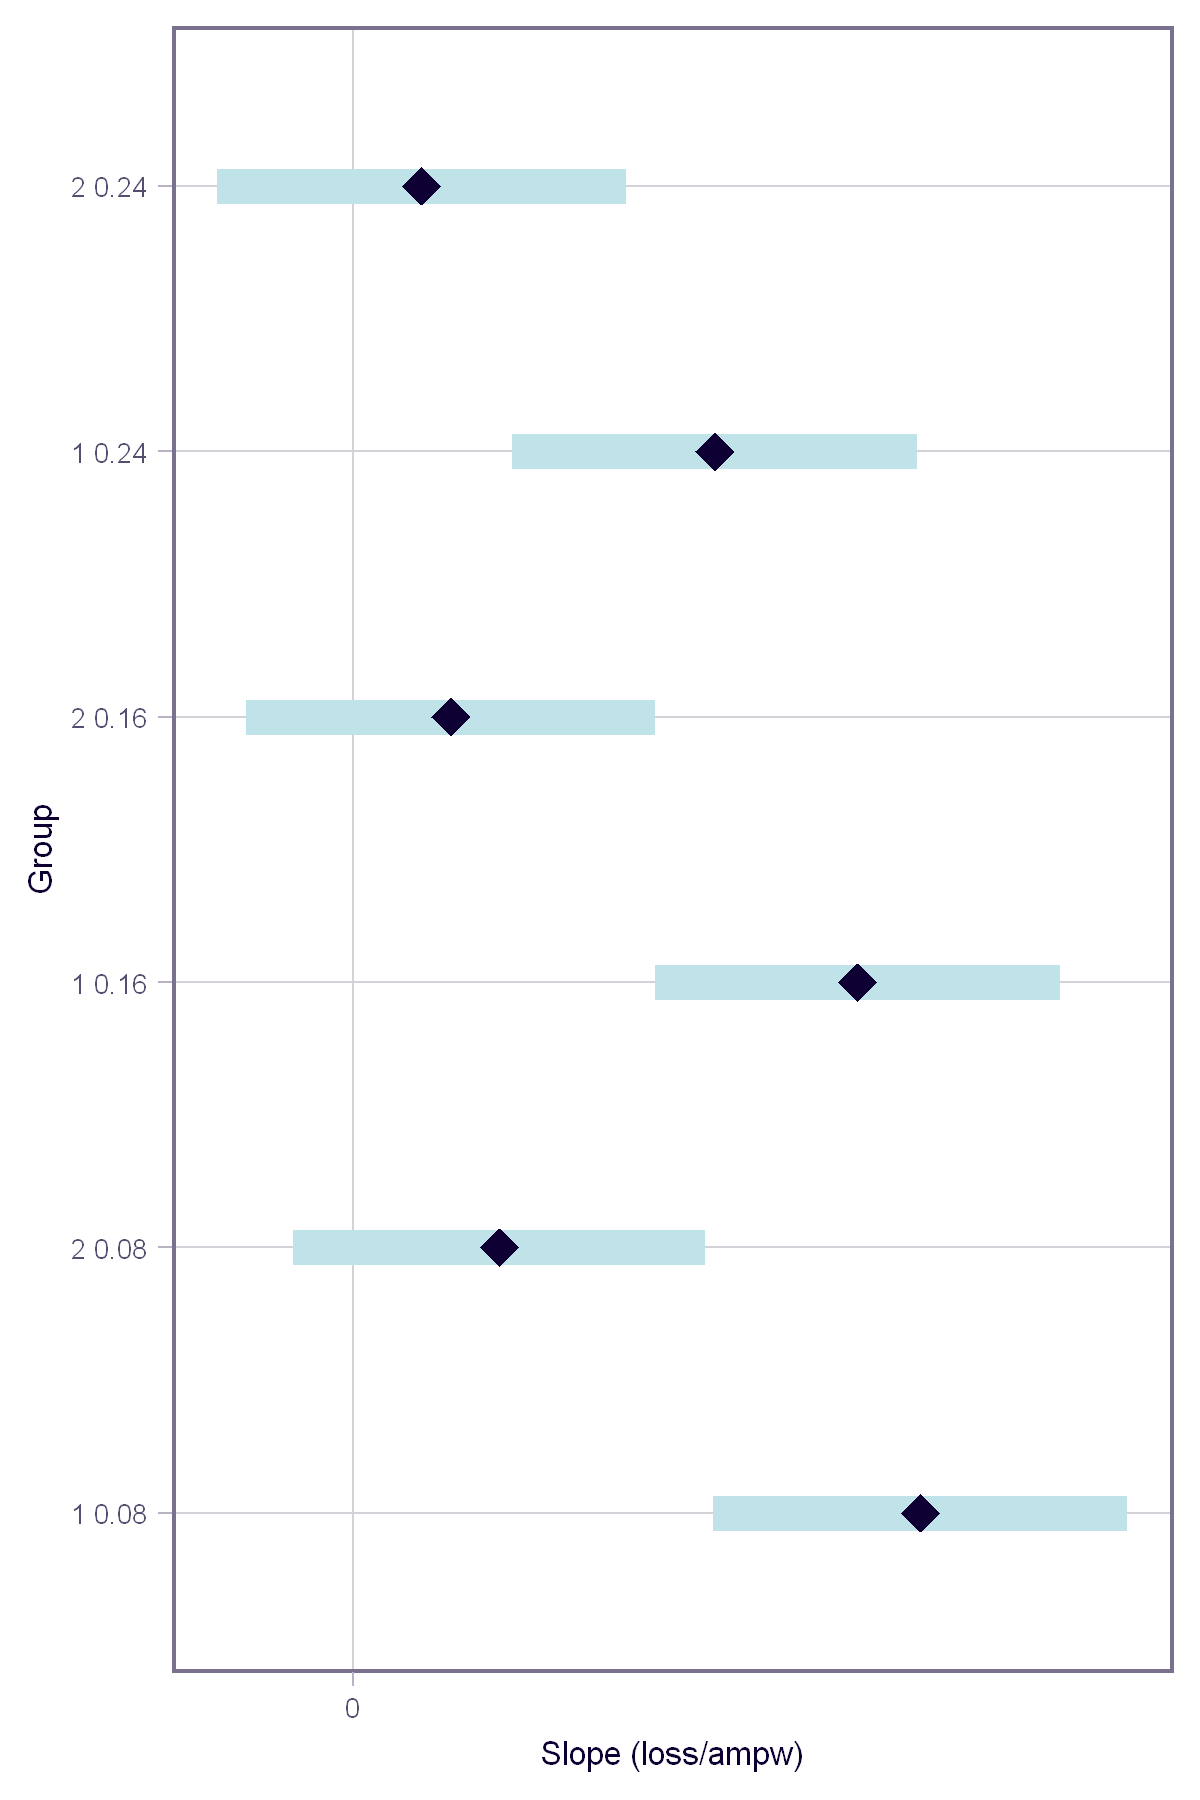

In [15]:
options(
    repr.plot.width = 4, 
    repr.plot.height = 6, 
    repr.plot.res = 300
)

emtrends(
    model, 
    var = 'ampw', 
    specs = c('v1_unit', 'upper_bound')
) %>% plot(comparisons = FALSE,) +     
    labs(
        x = 'Slope (loss/ampw)',
        y = 'Group',
    ) +
    geom_point(size=0.05)+
    theme(plot.title = element_text(hjust = 0.5)) +
    theme(text = element_text(size = 8)) +
    scale_x_continuous(labels = seq(0,250,10), breaks = seq(0,250,10))

In [ ]:
fixed_effects = as.data.frame(fixef(model))
fixed_effects

,fixef(model)
,<dbl>
(Intercept),0.066736641
ampw,0.618013289
v1_unit,0.003610818
upper_bound0.16,0.005935401
upper_bound0.24,0.012975441
ampw:v1_unit,-0.240868315


In [ ]:
random_effects = as.data.frame(ranef(model, condvar = TRUE))  %>% pivot_wider(
    names_from = term,
    values_from = c(condval, condsd)
)
random_effects

Warning message in ranef.merMod(model, condvar = TRUE):
"additional arguments to ranef.merMod ignored: condvar"


grpvar,grp,condval_(Intercept),condval_ampw,condsd_(Intercept),condsd_ampw
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
dlgn_unit,1_1,0.0103174636,0.08090092,0.0004960799,0.005612666
dlgn_unit,1_2,-0.0113004148,0.19230247,0.0005927961,0.015171213
dlgn_unit,1_3,0.0009829512,-0.27320339,0.0005577595,0.010304177
dlgn_unit,2_1,0.0041410838,-0.03561482,0.0005055241,0.004999294
dlgn_unit,2_2,-0.0035131098,0.10488053,0.0008325344,0.036592629
dlgn_unit,2_3,-0.0006279739,-0.06926571,0.0005140534,0.010911564


In [ ]:
write.csv(fixed_effects, 'ampw_fixef.csv')
write.csv(random_effects, 'ampw_ranef.csv')
write.csv(intercept_pred, 'ampw_intercepts.csv')
write.csv(slope_pred, 'ampw_slopes.csv')